LABTASK2


In [6]:
graph = {
    'Arad': ['Zerind', 'Sibiu', 'Timisoara'],
    'Zerind': ['Arad', 'Oradea'],
    'Oradea': ['Zerind', 'Sibiu'],
    'Sibiu': ['Arad', 'Oradea', 'Fagaras', 'Rimnicu Vilcea'],
    'Timisoara': ['Arad', 'Lugoj'],
    'Lugoj': ['Timisoara', 'Mehadia'],
    'Mehadia': ['Lugoj', 'Drobeta'],
    'Drobeta': ['Mehadia', 'Craiova'],
    'Craiova': ['Drobeta', 'Pitesti', 'Rimnicu Vilcea'],
    'Rimnicu Vilcea': ['Sibiu', 'Craiova', 'Pitesti'],
    'Fagaras': ['Sibiu', 'Bucharest'],
    'Pitesti': ['Rimnicu Vilcea', 'Craiova', 'Bucharest'],
    'Bucharest': []
}

In [7]:
from collections import deque

# BFS
def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])
    count = 0

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            count += 1

            if node == goal:
                return count

            for neighbor in graph[node]:
                queue.append(neighbor)

    return count


# DFS
def dfs(graph, start, goal, visited=None):
    if visited is None:
        visited = set()

    visited.add(start)
    count = 1

    if start == goal:
        return count

    for neighbor in graph[start]:
        if neighbor not in visited:
            result = dfs(graph, neighbor, goal, visited)
            if result:
                return count + result

    return count


# -------- CASE 1 --------
print("CASE 1: BFS < DFS")
start, goal = 'Arad', 'Sibiu'
print("BFS visited:", bfs(graph, start, goal))
print("DFS visited:", dfs(graph, start, goal))

# -------- CASE 2 --------
print("\nCASE 2: BFS > DFS")
start, goal = 'Arad', 'Bucharest'
print("BFS visited:", bfs(graph, start, goal))
print("DFS visited:", dfs(graph, start, goal))

CASE 1: BFS < DFS
BFS visited: 3
DFS visited: 4

CASE 2: BFS > DFS
BFS visited: 9
DFS visited: 6


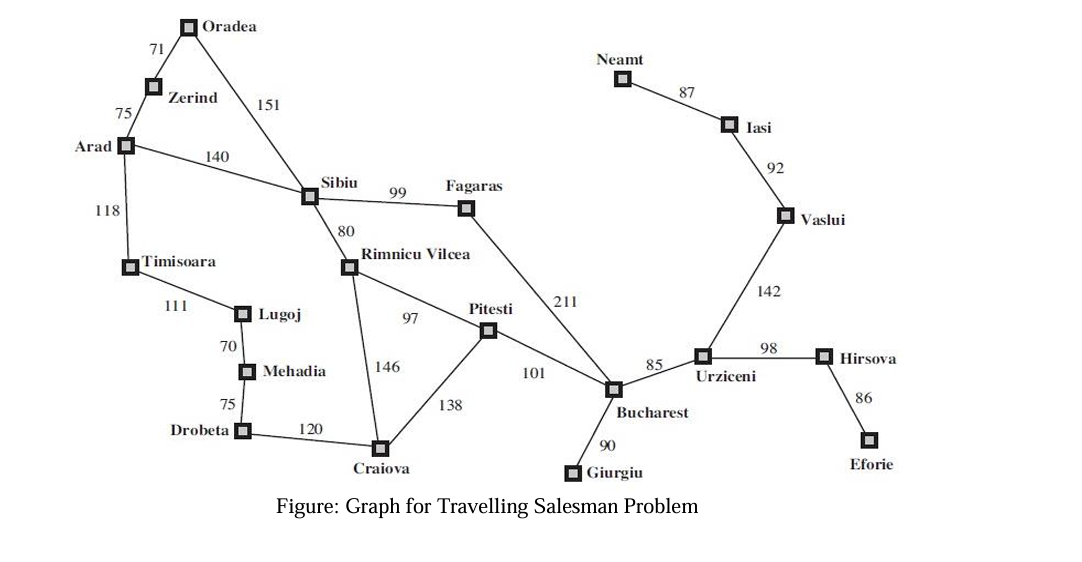

In [4]:
graph = {
    'Arad': [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)],
    'Zerind': [('Oradea', 71), ('Arad', 75)],
    'Oradea': [('Sibiu', 151), ('Zerind', 71)],
    'Timisoara': [('Lugoj', 111), ('Arad', 118)],
    'Lugoj': [('Mehadia', 70), ('Timisoara', 111)],
    'Mehadia': [('Drobeta', 75), ('Lugoj', 70)],
    'Drobeta': [('Craiova', 120), ('Mehadia', 75)],
    'Craiova': [('Pitesti', 138), ('Rimnicu Vilcea', 146), ('Drobeta', 120)],
    'Sibiu': [('Fagaras', 99), ('Rimnicu Vilcea', 80), ('Arad', 140), ('Oradea', 151)],
    'Rimnicu Vilcea': [('Pitesti', 97), ('Craiova', 146), ('Sibiu', 80)],
    'Fagaras': [('Bucharest', 211), ('Sibiu', 99)],
    'Pitesti': [('Bucharest', 101), ('Craiova', 138), ('Rimnicu Vilcea', 97)],
    'Bucharest': []
}

In [5]:


def dfs(graph, current, goal, visited, path, total_cost):

    visited.add(current)
    path.append(current)

    # Goal reached
    if current == goal:
        print("Path:", " -> ".join(path))
        print("Total Distance:", total_cost)
        return True

    # Explore neighbors
    for neighbor, cost in graph[current]:
        if neighbor not in visited:
            if dfs(graph, neighbor, goal, visited, path, total_cost + cost):
                return True

    # Backtracking
    path.pop()
    return False


# Driver Code
start = 'Arad'
goal = 'Bucharest'

visited = set()
path = []

print("DFS Path from Arad to Bucharest:\n")
dfs(graph, start, goal, visited, path, 0)

DFS Path from Arad to Bucharest:

Path: Arad -> Zerind -> Oradea -> Sibiu -> Fagaras -> Bucharest
Total Distance: 607


True

ACTIVITY 2
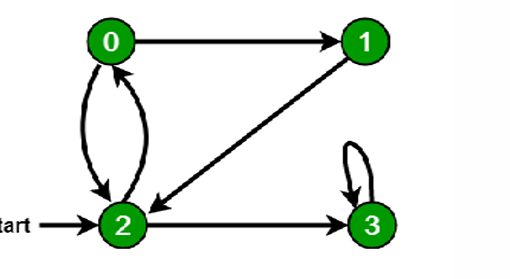

In [2]:
# DFS for a complete graph (Python 3 - Colab Ready)

from collections import defaultdict

# Graph class
class Graph:

    def __init__(self):
        self.graph = defaultdict(list)

    # Add edge
    def addEdge(self, u, v):
        self.graph[u].append(v)

    # DFS Utility function
    def DFSUtil(self, v, visited):

        visited[v] = True
        print(v, end=" ")

        # Visit all adjacent vertices
        for i in self.graph[v]:
            if not visited[i]:
                self.DFSUtil(i, visited)

    # DFS Traversal
    def DFS(self):
        V = max(self.graph) + 1   # total vertices (fix for safety)

        visited = [False] * V

        for i in range(V):
            if not visited[i]:
                self.DFSUtil(i, visited)


# Driver Code
g = Graph()

g.addEdge(0, 1)
g.addEdge(0, 2)
g.addEdge(1, 2)
g.addEdge(2, 0)
g.addEdge(2, 3)
g.addEdge(3, 3)

print("Following is Depth First Traversal:")
g.DFS()

Following is Depth First Traversal:
0 1 2 3 

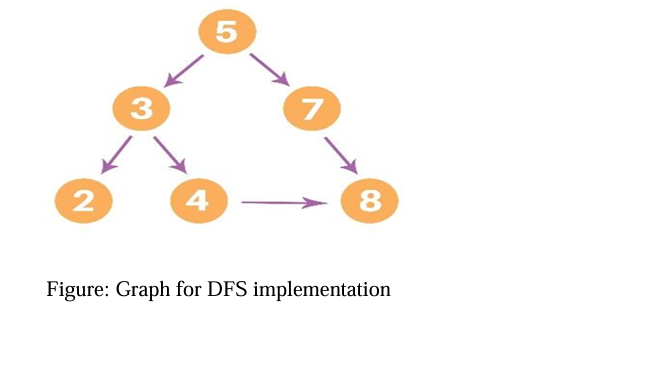

In [1]:
# Depth-First Search (DFS) using recursion

# Graph represented as adjacency list
graph = {
    '5': ['3', '7'],
    '3': ['2', '4'],
    '7': ['8'],
    '2': [],
    '4': ['8'],
    '8': []
}

# Set to keep track of visited nodes
visited = set()

# DFS function
def dfs(visited, graph, node):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)

# Driver code
print("DFS Traversal:")
dfs(visited, graph, '5')

DFS Traversal:
5 3 2 4 8 7 